In [17]:
import pandas as pd

df = pd.read_csv("Indian_Student_Placement_Dataset_2025.csv")

print("Rows and columns:", df.shape)
print("\nColumn info:")
print(df.head())


Rows and columns: (12000, 16)

Column info:
   student_id  gender  age degree      branch  cgpa  backlogs  internships  \
0           1    Male   20     BE  Mechanical  8.40         2            2   
1           2  Female   20  BTech  Electrical  8.60         2            0   
2           3    Male   22    BCA  Electrical  6.62         3            0   
3           4    Male   24    BCA          DS  8.01         0            0   
4           5    Male   24    BCA  Electrical  9.12         2            1   

   certifications  coding_skills  communication_skills  aptitude_score  \
0               2              1                     3              69   
1               5              1                     9              81   
2               1              1                     7              50   
3               4              4                     7              47   
4               2              4                     4              77   

   projects  placed company_type  package_

In [18]:
import pandas as pd
df = pd.read_csv("Indian_Student_Placement_Dataset_2025.csv")
print("Rows and columns:", df.shape)
print("\nColumn info:")
print("\nPreview:")
print(df.info())

Rows and columns: (12000, 16)

Column info:

Preview:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            12000 non-null  int64  
 1   gender                12000 non-null  str    
 2   age                   12000 non-null  int64  
 3   degree                12000 non-null  str    
 4   branch                12000 non-null  str    
 5   cgpa                  12000 non-null  float64
 6   backlogs              12000 non-null  int64  
 7   internships           12000 non-null  int64  
 8   certifications        12000 non-null  int64  
 9   coding_skills         12000 non-null  int64  
 10  communication_skills  12000 non-null  int64  
 11  aptitude_score        12000 non-null  int64  
 12  projects              12000 non-null  int64  
 13  placed                12000 non-null  int64  
 14  company_type          3652 

In [2]:
print(type(df))

<class 'pandas.DataFrame'>


In [5]:
# --- Duplicate Detection ---
# 1. Fully identical rows
duplicates_full = df.duplicated().sum()
print("Fully identical duplicates:", duplicates_full)
# 2. Duplicate student records using student_id
duplicates_key = df.duplicated(subset=["student_id"]).sum()
print("Duplicates by student_id:", duplicates_key)

Fully identical duplicates: 0
Duplicates by student_id: 0


In [6]:
missing_report = df.isnull().sum().to_frame("MissingCount")
missing_report["MissingPercent"] = (missing_report["MissingCount"] / len(df)) * 100
print("\nMissing Value Report:")
print(missing_report)



Missing Value Report:
                      MissingCount  MissingPercent
student_id                       0        0.000000
gender                           0        0.000000
age                              0        0.000000
degree                           0        0.000000
branch                           0        0.000000
cgpa                             0        0.000000
backlogs                         0        0.000000
internships                      0        0.000000
certifications                   0        0.000000
coding_skills                    0        0.000000
communication_skills             0        0.000000
aptitude_score                   0        0.000000
projects                         0        0.000000
placed                           0        0.000000
company_type                  8348       69.566667
package_lpa                      0        0.000000


In [4]:
# Remove duplicates

rows_before = len(df)

df_clean = df.drop_duplicates()

rows_after = len(df_clean)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Rows removed:", rows_before - rows_after)

# Continue using the cleaned dataframe
df = df_clean

Rows before removing duplicates: 12000
Rows after removing duplicates: 12000
Rows removed: 0


In [7]:
# Check zero values in numeric columns

numeric_columns = df.select_dtypes(include="number").columns

zero_report = (df[numeric_columns] == 0).sum()

print("\nZero Value Report:")
print(zero_report)


Zero Value Report:
student_id                 0
age                        0
cgpa                       0
backlogs                3031
internships             3021
certifications          1967
coding_skills              0
communication_skills       0
aptitude_score             0
projects                1970
placed                  8348
package_lpa             8348
dtype: int64


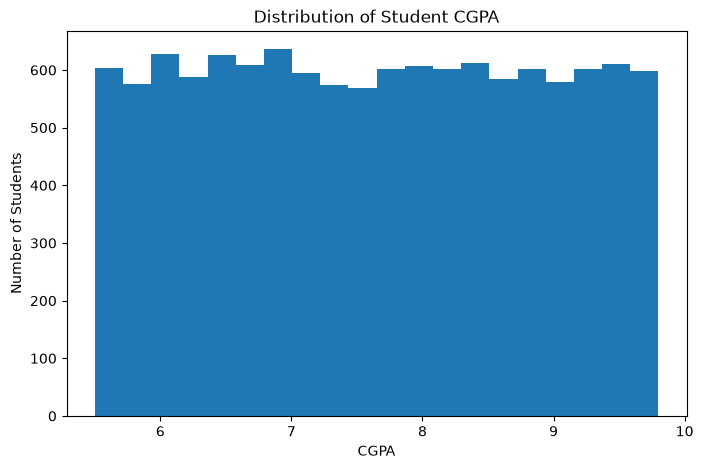

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["cgpa"].dropna(), bins=20)

plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.title("Distribution of Student CGPA")

plt.show()

In [9]:
cgpa_skewness = df["cgpa"].skew()

print("CGPA Skewness:", cgpa_skewness)

CGPA Skewness: 0.009837875656380224


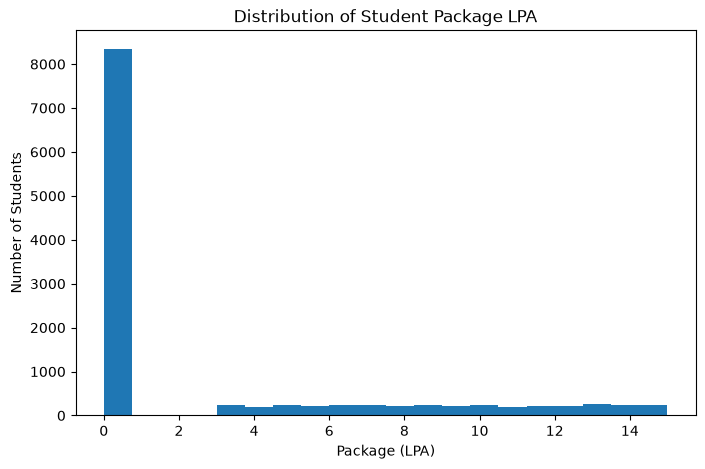

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["package_lpa"].dropna(), bins=20)

plt.xlabel("Package (LPA)")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Package LPA")

plt.show()

In [12]:
package_skewness = df["package_lpa"].skew()

print("Package LPA Skewness:", package_skewness)

Package LPA Skewness: 1.3635721764506636


In [10]:
# Handle missing company type

df["company_type"] = df["company_type"].fillna("Not Placed")

print("Missing company_type values:",
      df["company_type"].isnull().sum())

Missing company_type values: 0


In [13]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
student_id              0
gender                  0
age                     0
degree                  0
branch                  0
cgpa                    0
backlogs                0
internships             0
certifications          0
coding_skills           0
communication_skills    0
aptitude_score          0
projects                0
placed                  0
company_type            0
package_lpa             0
dtype: int64


In [14]:
total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 0


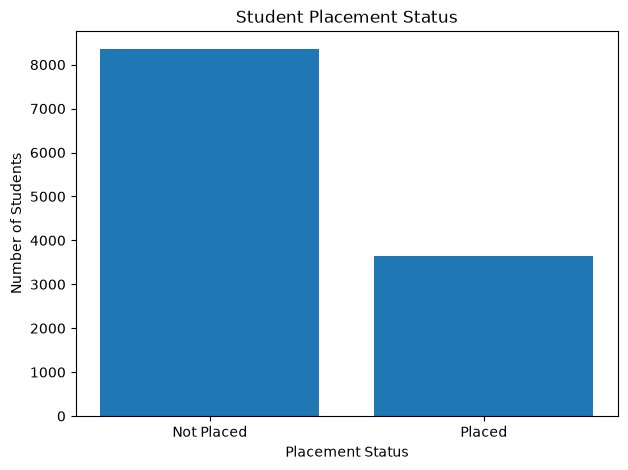

In [15]:
placement_counts = df["placed"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Not Placed", "Placed"],
    placement_counts.values
)

plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.title("Student Placement Status")

plt.show()

In [16]:
df.to_csv(
    "Indian_Student_Placement_Dataset_2025_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
